# Problem 3: Image Stacking algorithm

In this problem we will try to build an algorithm for stacking images. We simulate five consecutive frames of a star field with progressively degrading signal-to-noise ratios. 

We then apply four distinct stacking algorithms using algebraic loops to evaluate their effectiveness:
1. **Mean Stacking:** The mean of all the pixels in the stack is computed for each pixel.
2. **Median Stacking:** The median value of the pixels in the stack is computed for each pixel.
3. **Mean Kappa-Sigma:** This method is used to reject deviant pixels iteratively. Two parameters are used: the number of iterations and the standard deviation multiplier used (Kappa). For each iteration, the mean and standard deviation (Sigma) of the pixels in the stack are computed. Each pixel which value is farthest from the mean than more than $Kappa*Sigma$ is rejected. The mean of the remaining pixels in the stack is computed for each pixel.
4. **Median Kappa-Sigma:** This method is similar to the Mean Kappa-Sigma method but instead of rejected the pixel values, they are replaced by the median value.

In [16]:
import numpy as np

img_size = 100
base_sky_level = 300  

truth_image = np.full((img_size, img_size), base_sky_level, dtype=float)
x = np.arange(img_size)
y = np.arange(img_size)
X, Y = np.meshgrid(x, y)

# Defining stars: (Amplitude, X, Y, Sigma)
stars = [
    (1200, 25, 30, 2.0), 
    (800, 75, 80, 1.5),  
    (1500, 50, 50, 2.5), 
    (500, 85, 20, 1.8)   
]

for amp, xc, yc, sigma in stars:
    star_profile = amp * np.exp(-((X - xc)**2 + (Y - yc)**2) / (2 * sigma**2))
    truth_image += star_profile

# Using Gaussian noise into 5 separate frames
noise_levels = [5, 15, 35, 70, 120]
image_1 = truth_image + np.random.normal(0, noise_levels[0], (img_size, img_size))
image_2 = truth_image + np.random.normal(0, noise_levels[1], (img_size, img_size))
image_3 = truth_image + np.random.normal(0, noise_levels[2], (img_size, img_size))
image_4 = truth_image + np.random.normal(0, noise_levels[3], (img_size, img_size))
image_5 = truth_image + np.random.normal(0, noise_levels[4], (img_size, img_size))

print("Frames generated successfully.")

Frames generated successfully.


##  Stacking

To process these images we will iterate through the $100*100$ grid spatial coordinates manually. 

For every $X, Y$ coordinate, the loop gathers the five corresponding pixel values, calculates local statistical baselines (mean, median, and standard deviation), and applies the clipping logic pixel-by-pixel.

#### 1. Mean (Average)
**Population Mean:**
$$\mu = \frac{1}{N} \sum_{i=1}^{N} x_i$$

**Sample Mean:**
$$\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i$$

*Where:*
* $N$ or $n$ is the total number of data points.
* $x_i$ represents each individual value in the dataset.

#### 2. Median
**If $n$ is odd:**
The median is the exact middle value.
$$\text{Median} = x_{(n+1)/2}$$

**If $n$ is even:**
The median is the average of the two middle values.
$$\text{Median} = \frac{x_{n/2} + x_{(n/2) + 1}}{2}$$


#### 3. Standard Deviation
Standard deviation measures the amount of dispersion or spread of a set of values relative to its mean.

**Population Standard Deviation:**
$$\sigma = \sqrt{\frac{1}{N} \sum_{i=1}^{N} (x_i - \mu)^2}$$

**Sample Standard Deviation:**
$$s = \sqrt{\frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})^2}$$

*Where:*
* $\sigma$ is the population standard deviation, and $s$ is the sample standard deviation.
* $\mu$ is the population mean, and $\bar{x}$ is the sample mean.
* $(n-1)$ is Bessel's correction, which prevents underestimating the variance when working with a small sample rather than a full population.

In [ ]:
kappa = 2.0  

# Initializing blank stacked image arrays
stacked_mean = np.zeros((img_size, img_size))
stacked_median = np.zeros((img_size, img_size))
kappa_sigma_mean = np.zeros((img_size, img_size))
kappa_sigma_median = np.zeros((img_size, img_size))

for y in range(img_size):
    for x in range(img_size):
        # Extracting pixel across the 5 frames
        pixel_values = [
            image_1[y, x], 
            image_2[y, x], 
            image_3[y, x], 
            image_4[y, x], 
            image_5[y, x]
        ]
        
        local_mean = np.mean(pixel_values)
        local_median = np.median(pixel_values)
        local_std = np.std(pixel_values)
        
        # METHOD 1: Mean Stacking
        stacked_mean[y, x] = local_mean

        # METHOD 2: Median Stacking
        stacked_median[y, x] = local_median
        
        # METHOD 3: Mean Kappa-Sigma
        valid_pixels = []
        for val in pixel_values:
            if abs(val - local_mean) <= (kappa * local_std):
                valid_pixels.append(val)
                
        if len(valid_pixels) > 0:
            kappa_sigma_mean[y, x] = np.mean(valid_pixels)
        else:
            kappa_sigma_mean[y, x] = np.nan # stops python to throw an error when all pixels are outliers. 
            
        # METHOD 4: Median Kappa-Sigma
        corrected_pixels = []
        for val in pixel_values:
            if abs(val - local_median) > (kappa * local_std):
                corrected_pixels.append(local_median)
            else:
                corrected_pixels.append(val)
                
        kappa_sigma_median[y, x] = np.mean(corrected_pixels)

print("Stacking completed.")

Stacking completed.


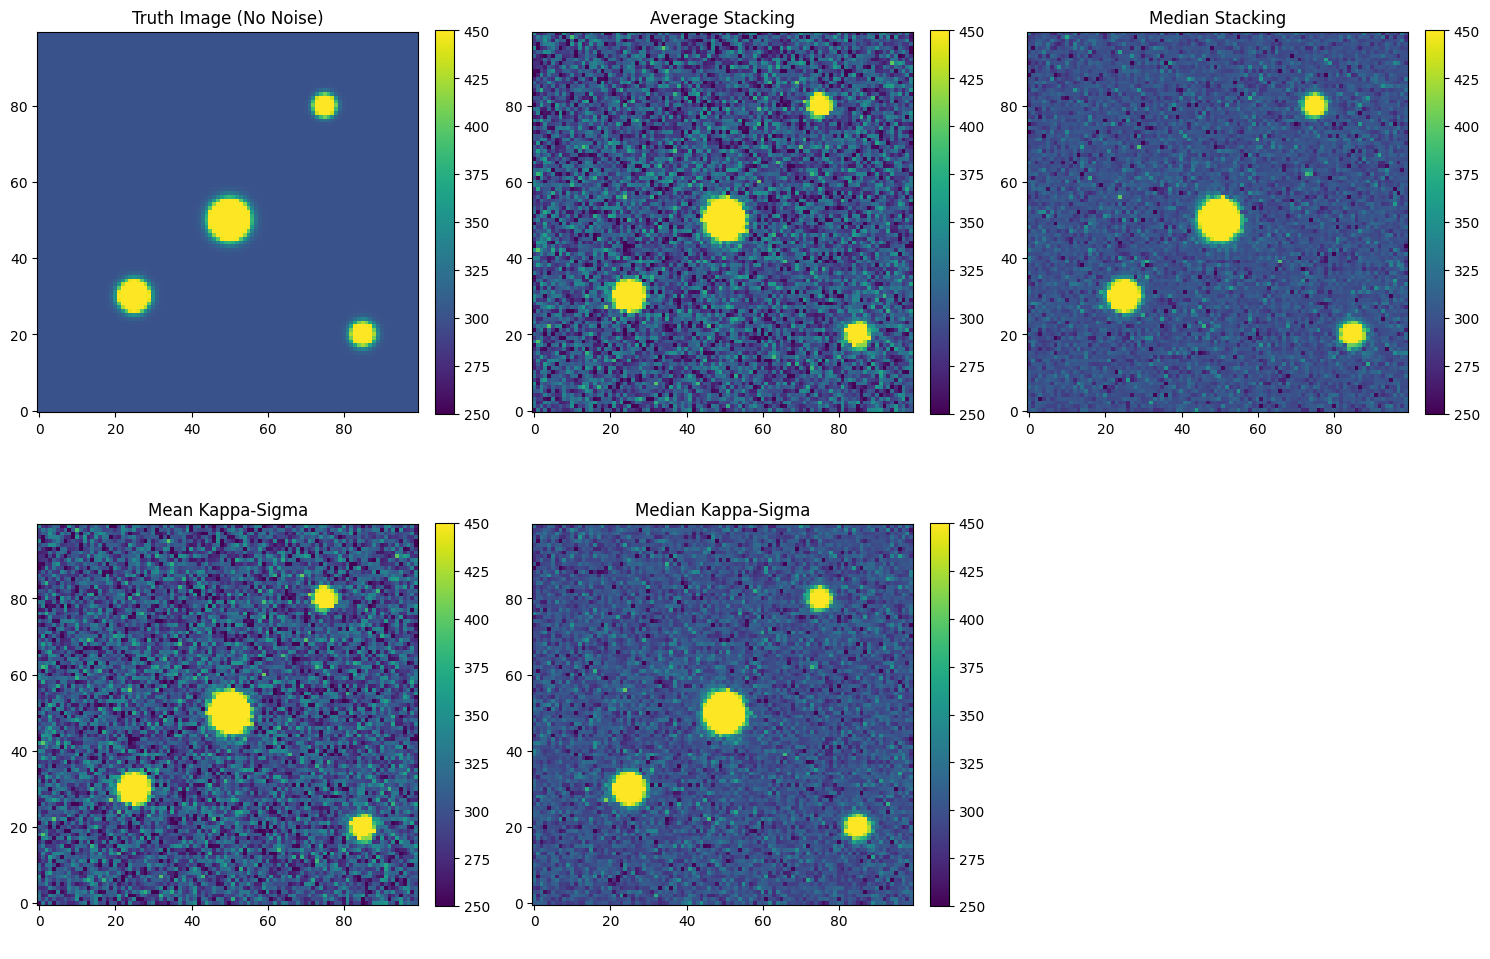

In [18]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

titles = [ "Truth Image (No Noise)", 
          "Average Stacking", "Median Stacking", 
          "Mean Kappa-Sigma", "Median Kappa-Sigma"]
          
images = [truth_image, stacked_mean, stacked_median, 
          kappa_sigma_mean, kappa_sigma_median]

for ax, title, img in zip(axes, titles, images):
    im = ax.imshow(img, cmap='viridis', origin='lower', vmin=250, vmax=450)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
axes[5].axis('off')
plt.tight_layout()
plt.show()

## Photometry
We test the geometric integrity of all the stacked images by passing it through our previously established photometry search algorithm. This verifies that the star signals were perfectly preserved while the surrounding noise was suppressed.

In [21]:
def photometry(image, num_stars=4, min_distance=15): 
    # need to remove the n_stars and min_distance parameters from the function definition, since we need to work with dense star fields.
    #  Also min_distance is not a good parameter to use in this case, since we are working with dense star fields.
    #  We will need to use a different approach to identify the stars in the image, like using a local maximum filter or a tolerence value.
    
    sorted_flat_indices = np.argsort(image.ravel())[::-1]
    star_centers = []
    
    for flat_index in sorted_flat_indices:
        y, x = np.unravel_index(flat_index, image.shape)
        too_close = False
        for (star_x, star_y) in star_centers:
            if (x - star_x)**2 + (y - star_y)**2 < (min_distance**2):
                too_close = True
                break
        if not too_close:
            star_centers.append((x, y))
        if len(star_centers) == num_stars:
            break
        
    y_grid, x_grid = np.mgrid[0:image.shape[0], 0:image.shape[1]]
    
    print("--- Photometry Results ---")
    for i, (x_c, y_c) in enumerate(star_centers):
        distance_sq = (x_grid - x_c)**2 + (y_grid - y_c)**2
        
        aperture_area = distance_sq <= 9
        aperture_flux = np.sum(image[aperture_area])
        n_pixels = np.sum(aperture_area)
        
        annulus_area = (distance_sq > 25) & (distance_sq <= 64)
        background_noise = np.median(image[annulus_area])
        
        net_flux = aperture_flux - (background_noise * n_pixels)
        if net_flux > 0:
            m_inst = -2.5 * np.log10(net_flux)
            print(f"Star {i+1} at (X={x_c}, Y={y_c}) | Net Flux: {net_flux:.2f} | m_inst: {m_inst:.3f}")

photometry(stacked_mean)
photometry(stacked_median)
photometry(kappa_sigma_mean)
photometry(kappa_sigma_median)


--- Photometry Results ---
Star 1 at (X=50, Y=50) | Net Flux: 29444.44 | m_inst: -11.173
Star 2 at (X=25, Y=30) | Net Flux: 20147.84 | m_inst: -10.761
Star 3 at (X=75, Y=80) | Net Flux: 10016.41 | m_inst: -10.002
Star 4 at (X=84, Y=20) | Net Flux: 7196.60 | m_inst: -9.643
--- Photometry Results ---
Star 1 at (X=50, Y=50) | Net Flux: 29191.11 | m_inst: -11.163
Star 2 at (X=25, Y=30) | Net Flux: 20342.00 | m_inst: -10.771
Star 3 at (X=75, Y=80) | Net Flux: 9904.14 | m_inst: -9.990
Star 4 at (X=85, Y=20) | Net Flux: 7526.93 | m_inst: -9.692
--- Photometry Results ---
Star 1 at (X=50, Y=50) | Net Flux: 29444.44 | m_inst: -11.173
Star 2 at (X=25, Y=30) | Net Flux: 20147.84 | m_inst: -10.761
Star 3 at (X=75, Y=80) | Net Flux: 10016.41 | m_inst: -10.002
Star 4 at (X=84, Y=20) | Net Flux: 7196.60 | m_inst: -9.643
--- Photometry Results ---
Star 1 at (X=50, Y=50) | Net Flux: 29491.78 | m_inst: -11.174
Star 2 at (X=25, Y=30) | Net Flux: 20270.47 | m_inst: -10.767
Star 3 at (X=75, Y=80) | Net Flu